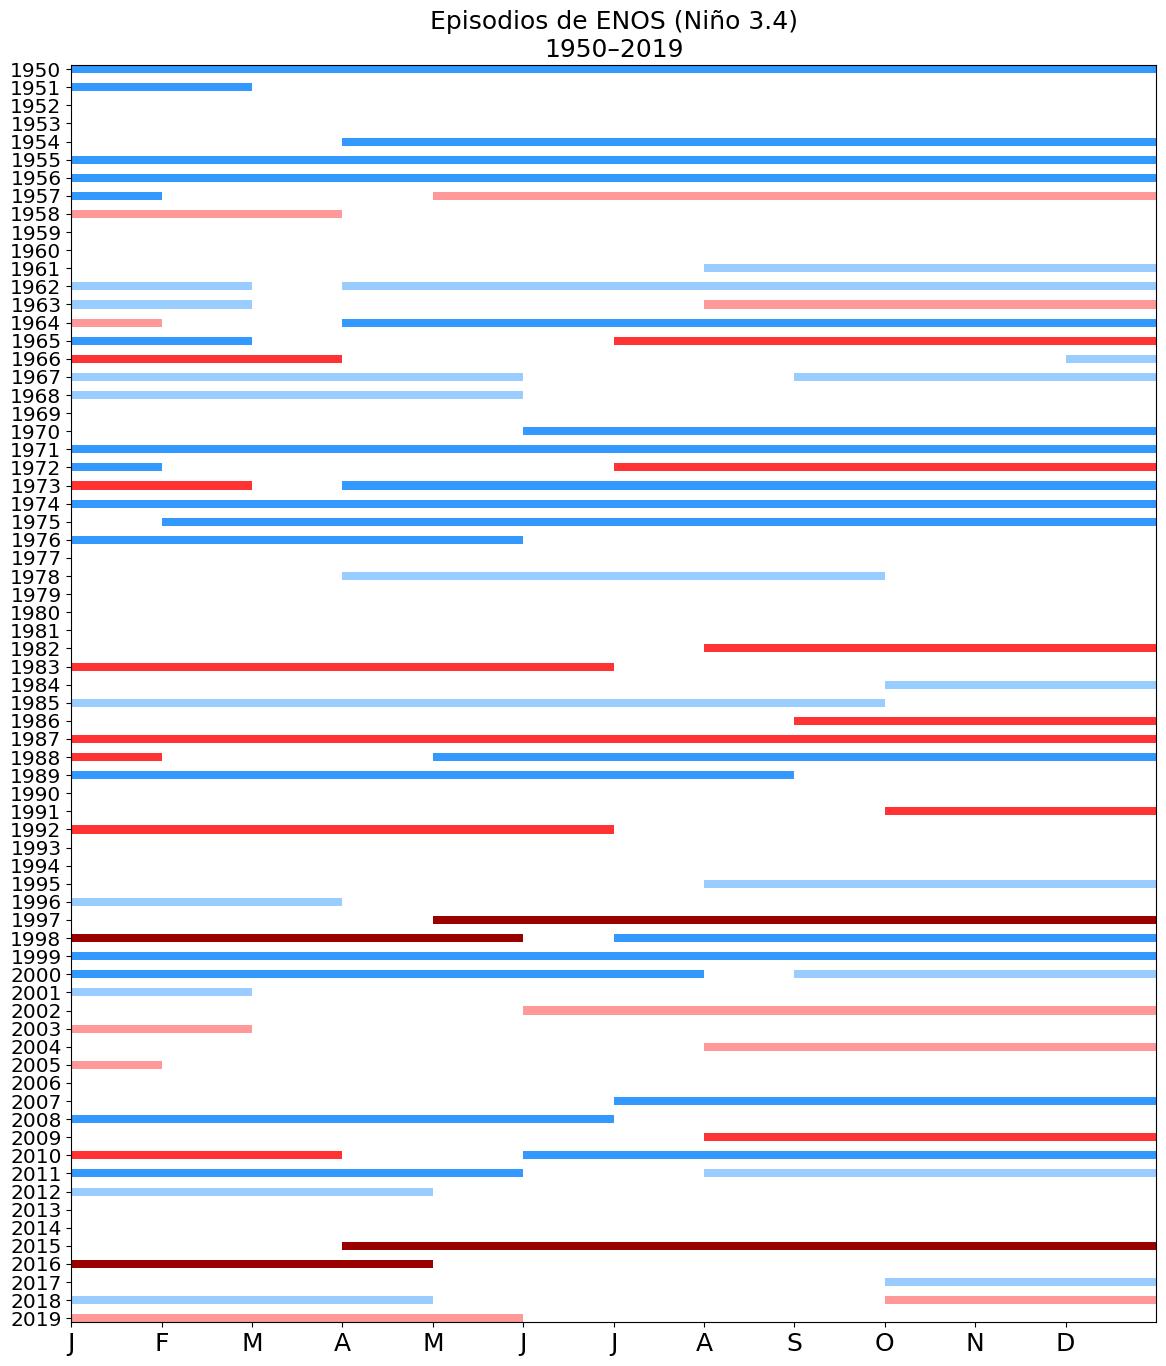

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0. Configuración global de fuente
# ============================================================

plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 14.5,
    'legend.fontsize': 18
})

# ============================================================
# 1. RUTA DEL ARCHIVO
# ============================================================

file_path = r"/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/DATOS/datos niño.xlsx"

# ============================================================
# 2. Cargar datos
# ============================================================

df = pd.read_excel(file_path)

# Tomar YR, MON y última columna (NINO3.4 ANOM)
df = df.iloc[:, [0, 1, -1]]
df.columns = ["Year", "Month", "Anomaly"]

df = df.sort_values(["Year", "Month"]).reset_index(drop=True)

# ============================================================
# 3. Detectar eventos ENSO
# ============================================================

df["Phase"] = np.where(df["Anomaly"] >= 0.5, 1,
                np.where(df["Anomaly"] <= -0.5, -1, 0))

df["Event"] = 0

current_phase = 0
count = 0
start_idx = 0

for i in range(len(df)):
    phase = df.loc[i, "Phase"]

    if phase == current_phase and phase != 0:
        count += 1
    else:
        if count >= 6 and current_phase != 0:
            df.loc[start_idx:i-1, "Event"] = current_phase

        current_phase = phase
        count = 1 if phase != 0 else 0
        start_idx = i

# último bloque
if count >= 6 and current_phase != 0:
    df.loc[start_idx:len(df)-1, "Event"] = current_phase

# ============================================================
# 4. Crear bloques de eventos continuos
# ============================================================

df["Block"] = (df["Event"] != df["Event"].shift()).cumsum()

# ============================================================
# 5. Filtrar intervalo 1950–2019
# ============================================================

df = df[(df["Year"] >= 1950) & (df["Year"] <= 2019)].reset_index(drop=True)

years = sorted(df["Year"].unique())

# ============================================================
# 6. Configuración de figura
# ============================================================

fig, ax = plt.subplots(figsize=(12, 14))

spacing = 1.8
bar_height = 0.8

# ============================================================
# 7. Función de color (igual que antes)
# ============================================================

def get_color_from_anomaly(anom):

    if anom > 0:
        if anom < 1.0:
            return "#ff9999"
        elif anom < 1.5:
            return "#ff3333"
        else:
            return "#990000"

    elif anom < 0:
        if anom > -1.0:
            return "#99ccff"
        elif anom > -1.5:
            return "#3399ff"
        else:
            return "#003366"

    return None

# ============================================================
# 8. Dibujar eventos por bloques (PROMEDIO)
# ============================================================

for block_id, group in df.groupby("Block"):

    # ignorar no-eventos
    if group["Event"].iloc[0] == 0:
        continue

    # promedio del evento
    mean_anom = group["Anomaly"].mean()

    color = get_color_from_anomaly(mean_anom)

    # dibujar mes a mes pero con MISMO color
    for i in range(len(group)):
        year = group.iloc[i]["Year"]
        month = int(group.iloc[i]["Month"]) - 1

        y_pos = years.index(year) * spacing

        ax.barh(y_pos,
                1,
                left=month,
                height=bar_height,
                color=color)

# ============================================================
# 9. Ajustes ejes
# ============================================================

ax.set_yticks(np.arange(len(years)) * spacing)
ax.set_yticklabels(years)

ax.set_xticks(np.arange(12))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

ax.set_xlim(0, 12)
ax.set_title("Episodios de ENOS (Niño 3.4)\n1950–2019")

# invertir eje para que 1950 esté arriba
ax.invert_yaxis()
ax.margins(x=0, y=0)
plt.tight_layout()
plt.savefig("Episodios_ENOS.png", dpi=300, bbox_inches='tight')
plt.show()

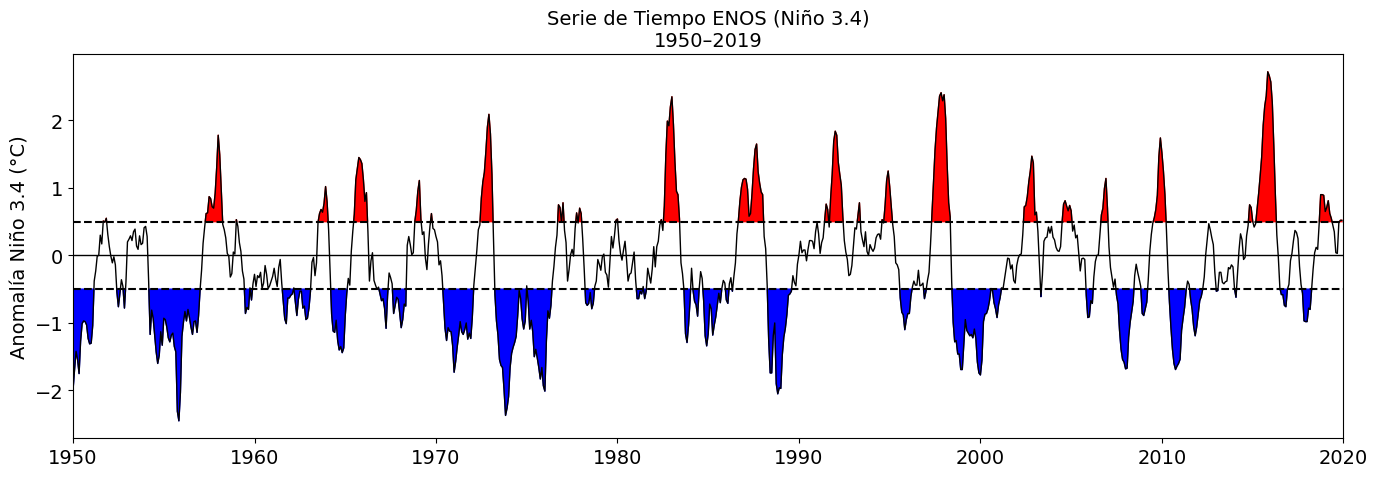

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0. Configuración global
# ============================================================

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})

# ============================================================
# 1. Ruta del archivo
# ============================================================

file_path = r"/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/DATOS/datos niño.xlsx"

# ============================================================
# 2. Cargar datos
# ============================================================

df = pd.read_excel(file_path)

df = df.iloc[:, [0, 1, -1]]
df.columns = ["Year", "Month", "Anomaly"]

df = df.sort_values(["Year", "Month"]).reset_index(drop=True)

# Crear eje temporal continuo
df["Time"] = df["Year"] + (df["Month"] - 1) / 12

# Filtrar intervalo
df = df[(df["Year"] >= 1950) & (df["Year"] <= 2019)]

# ============================================================
# 3. Gráfica
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

# Línea principal
ax.plot(df["Time"], df["Anomaly"], color="black", linewidth=1)

# ============================================================
# 4. Relleno por condiciones
# ============================================================

# Niño (rojo)
ax.fill_between(df["Time"],
                df["Anomaly"],
                0.5,
                where=(df["Anomaly"] >= 0.5),
                interpolate=True,
                color="red")

# Niña (azul)
ax.fill_between(df["Time"],
                df["Anomaly"],
                -0.5,
                where=(df["Anomaly"] <= -0.5),
                interpolate=True,
                color="blue")

# ============================================================
# 5. Líneas punteadas de referencia
# ============================================================

ax.axhline(0.5, linestyle="--",color="k")
ax.axhline(-0.5, linestyle="--",color="k")

# ============================================================
# 6. Eje X cada 10 años
# ============================================================

years_ticks = np.arange(1950, 2021, 10)
ax.set_xticks(years_ticks)
ax.set_xlim(1950, 2020)

# ============================================================
# 7. Etiquetas y título
# ============================================================

#ax.set_xlabel("Año")
ax.set_ylabel("Anomalía Niño 3.4 (°C)")
ax.set_title("Serie de Tiempo ENOS (Niño 3.4)\n1950–2019")

# Línea base
ax.axhline(0, linewidth=1,color="k")

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np

# ============================================================
# 1. Cargar datos
# ============================================================

file_path = r"/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/DATOS/datos niño.xlsx"

# Leer el archivo Excel
df = pd.read_excel(file_path)

# Tomar YR, MON y última columna (ANOM de NINO3.4)
df = df.iloc[:, [0, 1, -1]]
df.columns = ["Year", "Month", "Anomaly"]

# Ordenar cronológicamente
df = df.sort_values(["Year", "Month"]).reset_index(drop=True)

# ============================================================
# 2. Clasificar fase por signo
# ============================================================

df["Phase"] = np.where(df["Anomaly"] >= 0.5, 1,
                np.where(df["Anomaly"] <= -0.5, -1, 0))

# ============================================================
# 3. Detectar persistencia ≥ 6 meses consecutivos
# ============================================================

df["Event"] = 0

current_phase = 0
count = 0
start_idx = 0

for i in range(len(df)):
    phase = df.loc[i, "Phase"]

    if phase == current_phase and phase != 0:
        count += 1
    else:
        if count >= 6 and current_phase != 0:
            df.loc[start_idx:i-1, "Event"] = current_phase

        current_phase = phase
        count = 1 if phase != 0 else 0
        start_idx = i

# Verificar último bloque
if count >= 6 and current_phase != 0:
    df.loc[start_idx:len(df)-1, "Event"] = current_phase

# ============================================================
# 4. Limitar conteo hasta 2019
# ============================================================

df_count = df[df["Year"] <= 2019].copy()

# ============================================================
# 5. Contar eventos por año
# ============================================================

summary = []

for year in sorted(df_count["Year"].unique()):
    year_data = df_count[df_count["Year"] == year]

    eventos_nino = 0
    eventos_nina = 0

    prev = 0
    for val in year_data["Event"]:
        if val == 1 and prev != 1:
            eventos_nino += 1
        if val == -1 and prev != -1:
            eventos_nina += 1
        prev = val

    summary.append([year, eventos_nino, eventos_nina])

summary_df = pd.DataFrame(summary, columns=["Year", "Niños", "Niñas"])

# ============================================================
# 6. Mostrar resultados
# ============================================================

print("\nResumen por año (hasta 2019):")
print(summary_df)

print("\nTotal histórico hasta 2019:")
print("Total Niños:", summary_df["Niños"].sum())
print("Total Niñas:", summary_df["Niñas"].sum())

# ============================================================
# 7. Guardar a Excel
# ============================================================

output_file = "conteo_ENSO_por_año.xlsx"
summary_df.to_excel(output_file, index=False)

print(f"\nArchivo guardado como: {output_file}")


Resumen por año (hasta 2019):
    Year  Niños  Niñas
0   1950      0      1
1   1951      0      1
2   1952      0      0
3   1953      0      0
4   1954      0      1
..   ...    ...    ...
65  2015      1      0
66  2016      1      0
67  2017      0      1
68  2018      1      1
69  2019      1      0

[70 rows x 3 columns]

Total histórico hasta 2019:
Total Niños: 27
Total Niñas: 43

Archivo guardado como: conteo_ENSO_por_año.xlsx
